In [1]:
!pip install patchtst
!pip install neuralforecast
!pip install pytorch-lightning

ERROR: Could not find a version that satisfies the requirement patchtst (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for patchtst



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import torch

from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST

In [4]:
df = pd.read_csv(r"C:\Users\Avilasha\Desktop\CPU_Predictive_Maintenance\CPU\data\Processed\cpu_baseline.csv")

# timestamp conversion
df['ts'] = pd.to_datetime(
    df['ts'],
    format='mixed',
    utc=True
)
df = df.sort_values(['host_id', 'ts'])
df.head()

,id,ts,host_id,cpu_usage_pct,memory_usage_pct,power_kw,status,hostName,inlet_temp_c,cpu_temp_c,...,thermal_gradient,temp_rate_of_change,temp_roll_mean_12,cpu_per_kw,temp_per_cpu,resource_stress_index,timestamp_display,hour_of_day,day_of_week,is_weekend
49502,34,2026-04-02 12:44:09.710000+00:00,1,4.0,74.0,0.221,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.099548,7.600000,39.0,02-04-2026 12:44,12,3,0
49503,37,2026-04-02 12:46:02.041000+00:00,1,4.0,74.0,0.220,Normal,10.10.10.65,21,38,...,17,0.0,38.0,18.181818,7.600000,39.0,02-04-2026 12:46,12,3,0
49504,40,2026-04-02 12:47:28.840000+00:00,1,4.0,74.0,0.220,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.181818,7.600000,39.0,02-04-2026 12:47,12,3,0
49505,43,2026-04-02 12:49:08.515000+00:00,1,6.0,74.0,0.221,Normal,10.10.10.65,21,38,...,17,0.0,38.0,27.149321,5.428571,40.0,02-04-2026 12:49,12,3,0
49506,46,2026-04-02 12:51:17.199000+00:00,1,4.0,74.0,0.222,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.018018,7.600000,39.0,02-04-2026 12:51,12,3,0


In [5]:
# Select 1 server
server_df = df[df['host_id'] == 1].copy()
print(server_df.shape)

(24750, 31)


In [6]:
# Prepare PatchTST format
patch_df = server_df.copy()
patch_df = patch_df.rename(
    columns={
        'host_id':'unique_id',
        'ts':'ds',
        'cpu_usage_pct':'y'
    }
)
patch_df.head()

,id,ds,unique_id,y,memory_usage_pct,power_kw,status,hostName,inlet_temp_c,cpu_temp_c,...,thermal_gradient,temp_rate_of_change,temp_roll_mean_12,cpu_per_kw,temp_per_cpu,resource_stress_index,timestamp_display,hour_of_day,day_of_week,is_weekend
49502,34,2026-04-02 12:44:09.710000+00:00,1,4.0,74.0,0.221,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.099548,7.600000,39.0,02-04-2026 12:44,12,3,0
49503,37,2026-04-02 12:46:02.041000+00:00,1,4.0,74.0,0.220,Normal,10.10.10.65,21,38,...,17,0.0,38.0,18.181818,7.600000,39.0,02-04-2026 12:46,12,3,0
49504,40,2026-04-02 12:47:28.840000+00:00,1,4.0,74.0,0.220,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.181818,7.600000,39.0,02-04-2026 12:47,12,3,0
49505,43,2026-04-02 12:49:08.515000+00:00,1,6.0,74.0,0.221,Normal,10.10.10.65,21,38,...,17,0.0,38.0,27.149321,5.428571,40.0,02-04-2026 12:49,12,3,0
49506,46,2026-04-02 12:51:17.199000+00:00,1,4.0,74.0,0.222,Normal,10.10.10.65,19,38,...,19,0.0,38.0,18.018018,7.600000,39.0,02-04-2026 12:51,12,3,0


In [11]:
patch_df = patch_df[[
    'unique_id',
    'ds',
    'y',
    'memory_usage_pct',
    'power_kw',
    'cpu_temp_c',
    'inlet_temp_c',
    'cpu_lag_1',
    'cpu_lag_2',
    'cpu_change',
    'cpu_roll_mean_3',
    'cpu_volatility',
    'resource_stress_index',
    'hour_of_day',
    'day_of_week',
    'is_weekend'
]]

In [12]:
# Exogenours Features
EXOGENOUS = [
    'memory_usage_pct',
    'power_kw',
    'cpu_temp_c',
    'inlet_temp_c',
    'cpu_lag_1',
    'cpu_lag_2',
    'cpu_change',
    'cpu_roll_mean_3',
    'cpu_volatility',
    'resource_stress_index',
    'hour_of_day',
    'day_of_week',
    'is_weekend'
]

In [13]:
# Train-test split
split_idx = int(len(patch_df) * 0.8)
train_df = patch_df.iloc[:split_idx]
test_df = patch_df.iloc[split_idx:]
print(train_df.shape)
print(test_df.shape)

(19800, 16)
(4950, 16)


1 HOUR MODEL

In [14]:
# 5min sampling = 1 hour = 12 timestamps
INPUT_SIZE = 12

# create patchTST
model = PatchTST(
    h=1,
    input_size=INPUT_SIZE,
    patch_len=4,
    stride=2,
    hidden_size=64,
    n_heads=4,
    scaler_type='standard',
    max_steps=1000
)

Seed set to 1


In [15]:
# Train model
nf = NeuralForecast(
    models=[model],
    freq='5min'
)
nf.fit(train_df)

# Forecast
forecast = nf.predict()
forecast.head()

# Merge predictions
actual = test_df['y'].iloc[:len(forecast)]
pred = forecast['PatchTST']
results = pd.DataFrame({
    'Actual': actual.values,
    'Prediction': pred.values
})
results.head()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 151 K  | train
-----------------------------------------------------------
151 K     Trainable params
3         Non-trainable params
151 K     Total params
0.604     Total estimated model

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

,Actual,Prediction
0,1.0,1.012736


In [18]:
print(len(train_df))
print(len(test_df))
print(len(forecast))
print(forecast.head())

19800
4950
1
   unique_id                               ds  PatchTST
0          1 2026-05-25 00:04:20.317000+00:00  1.012736


In [16]:
# Metrics
mae = mean_absolute_error(
    results['Actual'],
    results['Prediction']
)
rmse = np.sqrt(
    mean_squared_error(
        results['Actual'],
        results['Prediction']
    )
)
r2 = r2_score(
    results['Actual'],
    results['Prediction']
)
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.012735605239868164
RMSE: 0.012735605239868164
R2  : nan


c:\Users\Avilasha\Desktop\handwriting-ocr\cuda_env\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


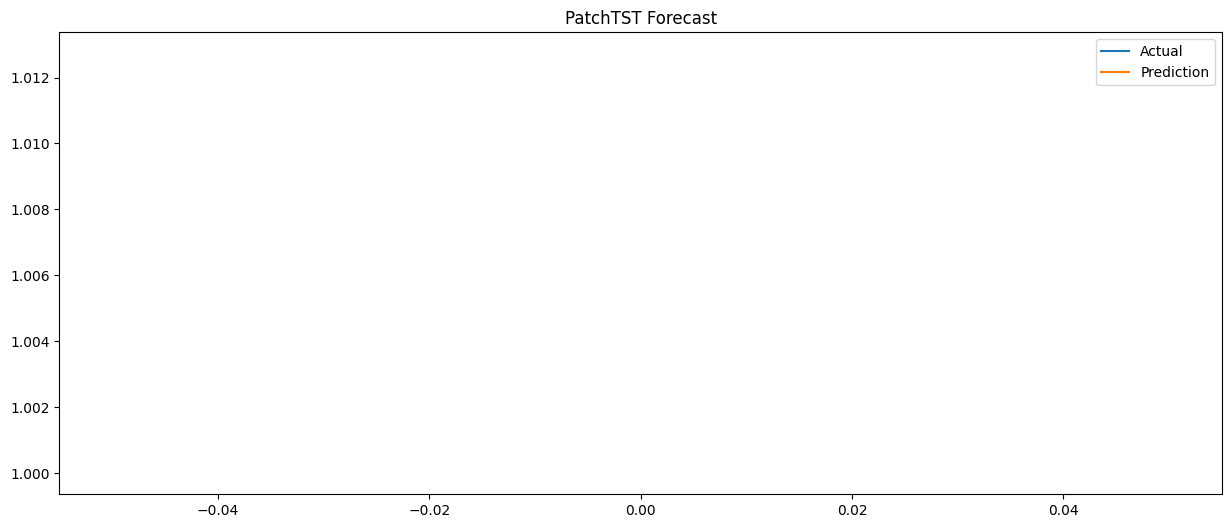

In [17]:
# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
plt.plot(
    results['Actual'],
    label='Actual'
)
plt.plot(
    results['Prediction'],
    label='Prediction'
)
plt.legend()
plt.title("PatchTST Forecast")
plt.show()